## 2. Data Description and Visualization

In this phase, provide an overview of the distribution of the outcome variables and select a
few key features for visualization. Present these insights using graphical representations
and a summary table of measures. You can refer to the RandomForestDemo notebook for
inspiration.

Additionally, a starter notebook is provided where a visual representation of the biomes
(Biome_obs) are showed on a global map.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
import shap
import seaborn as sns

### 2.1 Load and print datafiles

In [22]:
#LPJ-GUESS output
lpj_df = pd.read_csv("../data/LPJ-GUESS_output_BERN1.csv")
lpj_df.head()

,Lon,Lat,NPP,SoilR,MaxBiomeCmax,MaxBiomeLAI,VegC,LitterC,SoilC,Biome_Cmax,Biome_LAI,Biome_obs
0,39.75,-1.25,0.429,0.390,0.449,1.9821,1.225,0.758,5.941,8,12,12
1,150.25,-34.25,0.554,0.451,6.883,3.3174,6.953,3.221,10.566,7,7,6
2,-63.75,82.75,0.000,0.000,0.000,0.0000,0.000,0.003,0.002,13,13,17
3,59.25,30.75,0.043,0.042,0.090,0.2146,0.127,0.084,0.543,7,11,14
4,24.25,27.75,0.000,0.000,0.000,0.0000,0.000,0.000,0.000,13,13,17


In [3]:
# Grid information
grid_df = pd.read_csv("../data/gridlist_pan_gfed_ISO3_UN_ecoregion.txt",sep=" ")
grid_df.head()


,Lon,Lat,GFED-region,Pan_2007,ISO3,UN,Ecoregion
0,-69.75,-55.25,5,Americas,CHL,152,4
1,-69.25,-55.25,5,Americas,CHL,152,4
2,-71.25,-54.75,5,Americas,CHL,152,4
3,-70.75,-54.75,5,Americas,CHL,152,4
4,-70.25,-54.75,5,Americas,CHL,152,4


In [4]:
# Soil texture
soil_df = pd.read_csv("../data/soilmap.dat",sep="\t")
soil_df.head()

,lon,lat,clay,silt,sand,orgC,CN,pH,cellfraction
0,-179.75,71.25,0.08,0.37,0.55,0.020,11.0,5.9,0.482
1,-179.75,68.75,0.20,0.48,0.32,0.031,17.0,6.3,0.753
2,-179.75,68.25,0.20,0.48,0.32,0.031,17.0,6.3,0.447
3,-179.75,67.75,0.20,0.48,0.32,0.031,17.0,6.3,0.526
4,-179.75,67.25,0.20,0.48,0.32,0.031,17.0,6.3,0.422


In [5]:
# Load all climate datafiles and put in one dictionary
climate_files = {
    "tswrf": "../data/Tswrfdaymean1961_1990.csv",
    "pre": "../data/Predaymean1961_1990.csv",
    "tmp": "../data/Tmpdaymean1961_1990.csv",
    "tmax": "../data/Tmaxdaymean1961_1990.csv",
    "tmin": "../data/Tmindaymean1961_1990.csv"}

climate_df = {}
for name, path in climate_files.items():
    climate_df[name] = pd.read_csv(path)

# Load all climate statistics datafiles and put in one dictionary
stats_files = {
    "tswrf": "../data/Tswrfdaymean1961_1990_stats.csv",
    "pre": "../data/Predaymean1961_1990_stats.csv",
    "tmp": "../data/Tmpdaymean1961_1990_stats.csv",
    "tmax": "../data/Tmaxdaymean1961_1990_stats.csv",
    "tmin": "../data/Tmindaymean1961_1990_stats.csv"}

stats_df = {}
for name, path in stats_files.items():
    stats_df[name] = pd.read_csv(path)

In [6]:
# Tswrf: Total shortwave radiation flux (W m⁻²)
climate_df["tswrf"].head()

,Lon,Lat,Day1,Day2,Day3,Day4,Day5,Day6,Day7,Day8,...,Day356,Day357,Day358,Day359,Day360,Day361,Day362,Day363,Day364,Day365
0,39.75,-1.25,231.59,219.87,236.62,238.73,239.37,250.71,236.94,236.88,...,205.60,223.60,195.67,198.74,203.09,193.82,210.05,199.19,223.03,220.83
1,150.25,-34.25,306.97,311.71,310.55,311.11,311.43,304.95,312.76,312.54,...,305.95,301.99,296.33,301.22,287.30,293.39,301.39,296.81,296.34,279.91
2,-63.75,82.75,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,59.25,30.75,133.78,137.99,136.90,126.10,145.59,132.06,136.92,132.72,...,145.09,125.97,127.70,125.30,137.31,113.15,117.91,131.45,134.91,128.61
4,24.25,27.75,144.89,153.19,155.81,165.83,163.23,163.97,153.20,162.64,...,144.84,150.68,153.20,151.03,158.60,153.69,153.10,160.78,152.35,146.26


In [7]:
# Pre: Precipitation (mm day⁻¹)
climate_df["pre"].head()

,Lon,Lat,Day1,Day2,Day3,Day4,Day5,Day6,Day7,Day8,...,Day356,Day357,Day358,Day359,Day360,Day361,Day362,Day363,Day364,Day365
0,39.75,-1.25,0.634400,0.838580,1.373300,1.487800,0.948640,0.705560,0.790570,0.69274,...,1.260600,1.011600,2.676200,2.146300,0.83299,0.97611,1.092800,2.015100,1.220200,1.064100
1,150.25,-34.25,3.176800,3.282800,4.271300,2.735100,3.118300,1.863200,2.245400,1.81270,...,1.243100,2.901500,1.580400,2.788500,3.62270,2.12350,2.546700,2.624700,1.521800,2.259400
2,-63.75,82.75,0.191720,0.553370,0.559100,0.350270,0.414340,0.239620,0.215600,0.39415,...,0.286600,0.187410,0.352480,0.303120,0.37439,0.29827,0.399200,0.162680,0.180370,0.251560
3,59.25,30.75,0.272920,0.576200,1.529900,0.475970,0.809060,0.772860,0.773340,0.12219,...,0.315400,0.223630,0.009584,0.004932,0.65535,1.25430,0.680690,0.534400,0.225750,0.281360
4,24.25,27.75,0.012822,0.044511,0.027133,0.003318,0.007306,0.014162,0.085964,0.01347,...,0.029099,0.040272,0.030631,0.000518,0.00058,0.12653,0.010889,0.002139,0.003662,0.009687


In [8]:
# Tmp: Daily mean temperature (K)
climate_df["tmp"].head()

,Lon,Lat,Day1,Day2,Day3,Day4,Day5,Day6,Day7,Day8,...,Day356,Day357,Day358,Day359,Day360,Day361,Day362,Day363,Day364,Day365
0,39.75,-1.25,301.11,301.14,301.07,300.95,301.14,301.32,301.33,301.33,...,301.49,301.63,301.19,301.11,301.15,301.39,301.33,301.40,301.49,301.39
1,150.25,-34.25,293.59,293.28,293.53,292.33,292.28,292.75,292.78,293.84,...,293.04,292.88,292.75,293.03,292.37,292.62,293.36,292.90,293.58,292.72
2,-63.75,82.75,241.33,242.18,242.51,241.94,241.99,241.18,240.35,240.29,...,242.67,243.21,244.22,243.65,242.88,241.99,243.01,243.91,244.09,243.10
3,59.25,30.75,281.13,281.06,281.34,282.07,281.57,281.56,282.13,282.14,...,283.05,282.85,282.33,281.68,281.74,281.59,281.69,281.00,281.42,281.48
4,24.25,27.75,285.84,285.50,285.25,285.06,284.62,285.04,285.01,284.48,...,285.96,285.78,285.66,285.68,285.39,285.57,285.62,285.71,285.71,285.66


In [9]:
# Tmax: Daily maximum temperature (K)
climate_df["tmax"].head()

,Lon,Lat,Day1,Day2,Day3,Day4,Day5,Day6,Day7,Day8,...,Day356,Day357,Day358,Day359,Day360,Day361,Day362,Day363,Day364,Day365
0,39.75,-1.25,302.63,302.91,302.83,302.43,302.76,302.99,302.95,303.04,...,302.96,303.14,302.65,302.49,302.66,302.87,302.73,302.76,302.99,302.98
1,150.25,-34.25,296.43,296.09,295.97,294.85,294.73,295.55,295.77,296.80,...,296.44,296.16,295.83,296.28,295.14,295.86,296.45,296.14,296.54,294.66
2,-63.75,82.75,244.72,245.60,245.89,245.11,244.98,244.50,243.61,243.90,...,246.04,246.82,247.53,247.26,246.58,246.02,246.67,247.49,247.69,246.57
3,59.25,30.75,284.75,284.92,285.61,286.23,285.53,285.78,286.21,285.91,...,287.97,288.04,287.38,286.80,287.24,287.00,286.86,286.56,286.61,286.65
4,24.25,27.75,290.05,289.76,289.50,289.10,289.05,289.41,289.26,288.84,...,290.04,289.73,289.58,289.62,289.48,289.77,289.97,290.24,290.17,289.90


In [10]:
# Tmin: Daily minimum temperature (K)
climate_df["tmin"].head()

,Lon,Lat,Day1,Day2,Day3,Day4,Day5,Day6,Day7,Day8,...,Day356,Day357,Day358,Day359,Day360,Day361,Day362,Day363,Day364,Day365
0,39.75,-1.25,296.63,296.49,296.55,296.51,296.69,296.64,296.68,296.74,...,296.54,296.48,296.30,296.23,296.26,296.29,296.46,296.43,296.55,296.83
1,150.25,-34.25,290.14,289.85,289.86,288.98,288.74,289.37,289.22,290.43,...,289.51,289.81,289.54,289.99,289.32,289.53,290.06,289.90,290.14,289.41
2,-63.75,82.75,240.80,241.47,241.86,241.37,241.49,240.74,239.82,239.64,...,241.86,242.46,243.48,242.96,242.10,241.31,242.23,243.03,242.98,242.13
3,59.25,30.75,278.46,278.36,278.70,279.43,279.03,279.01,279.38,279.36,...,278.97,278.82,278.43,278.07,277.74,277.97,277.98,277.51,277.71,277.86
4,24.25,27.75,284.46,283.98,283.83,283.46,283.21,283.67,283.66,283.15,...,284.47,284.35,284.12,284.14,283.96,284.09,284.21,284.29,284.28,284.57


In [11]:
# Tswrf: Total shortwave radiation flux (W m⁻²)
stats_df["tswrf"].head()

,Lon,Lat,SpringMean,SpringMedian,SpringStd,SummerMean,SummerMedian,SummerStd,FallMean,FallMedian,FallStd,WinterMean,WinterMedian,WinterStd
0,39.75,-1.25,245.3500,243.31,12.278,224.76,223.69,14.020,212.13,209.70,17.828,230.61000,233.69,13.8210
1,150.25,-34.25,273.2400,280.66,31.715,143.77,134.31,30.976,168.57,159.00,40.282,277.94000,279.75,26.3640
2,-63.75,82.75,6.8325,0.00,14.407,214.38,238.73,68.931,140.85,142.78,85.973,0.43718,0.00,1.5824
3,59.25,30.75,176.1900,170.71,37.004,312.30,323.65,34.345,286.04,287.80,31.122,160.32000,153.34,34.7040
4,24.25,27.75,207.9700,200.82,38.315,308.44,311.95,20.496,302.93,307.45,23.021,189.10000,185.46,32.6170


In [12]:
# Pre: Precipitation (mm day⁻¹)
stats_df["pre"].head()

,Lon,Lat,SpringMean,SpringMedian,SpringStd,SummerMean,SummerMedian,SummerStd,FallMean,FallMedian,FallStd,WinterMean,WinterMedian,WinterStd
0,39.75,-1.25,0.870380,0.693390,0.641700,1.622500,1.30490,1.11930,0.528780,0.450650,0.315910,2.049600,1.836000,1.289100
1,150.25,-34.25,3.251700,2.971600,1.559000,2.418500,2.07100,1.51770,1.725700,1.331900,1.054600,2.547500,2.358200,1.253600
2,-63.75,82.75,0.234270,0.209640,0.139210,0.333730,0.31885,0.18320,0.758070,0.735040,0.338730,0.325480,0.296160,0.154960
3,59.25,30.75,0.715820,0.592520,0.423350,0.136010,0.03079,0.17825,0.005847,0.000000,0.020282,0.180990,0.045619,0.278850
4,24.25,27.75,0.045284,0.015422,0.070006,0.061916,0.01050,0.10039,0.004480,0.000016,0.022542,0.028823,0.006414,0.055641


In [13]:
# Tmp: Daily mean temperature (K)
stats_df["tmp"].head()

,Lon,Lat,SpringMean,SpringMedian,SpringStd,SummerMean,SummerMedian,SummerStd,FallMean,FallMedian,FallStd,WinterMean,WinterMedian,WinterStd
0,39.75,-1.25,302.34,302.33,0.6554,301.21,301.20,1.3120,299.60,299.65,0.46193,301.42,301.39,0.44815
1,150.25,-34.25,292.82,292.97,1.1691,284.64,284.10,2.7774,282.29,281.50,1.80220,289.77,289.76,2.17460
2,-63.75,82.75,240.12,240.07,1.2096,260.31,261.44,10.1770,271.20,274.13,5.88880,247.77,245.76,4.80570
3,59.25,30.75,285.40,284.89,3.3975,299.63,300.13,4.0871,302.39,303.13,2.64690,288.71,287.35,4.84480
4,24.25,27.75,287.69,287.32,2.6203,299.53,299.15,2.9706,301.97,302.61,1.34370,291.17,290.75,4.37740


In [14]:
# Tmax: Daily maximum temperature (K)
stats_df["tmax"].head()

,Lon,Lat,SpringMean,SpringMedian,SpringStd,SummerMean,SummerMedian,SummerStd,FallMean,FallMedian,FallStd,WinterMean,WinterMedian,WinterStd
0,39.75,-1.25,304.27,304.43,0.74315,302.40,302.40,1.0318,301.13,301.11,0.39706,302.66,302.62,0.4142
1,150.25,-34.25,295.36,295.46,1.20660,288.11,287.64,3.0125,285.74,284.94,1.78200,293.06,293.14,2.1944
2,-63.75,82.75,243.87,243.72,1.14260,263.31,264.06,9.1992,272.13,274.69,5.69120,250.88,249.34,4.3383
3,59.25,30.75,288.82,287.81,3.27200,304.98,306.09,4.5394,307.99,308.63,2.57240,294.33,293.13,5.0202
4,24.25,27.75,291.96,291.66,2.65600,303.90,303.83,3.3008,306.28,306.87,1.23550,295.48,295.23,4.3877


In [15]:
# Tmin: Daily minimum temperature (K)
stats_df["tmin"].head()

,Lon,Lat,SpringMean,SpringMedian,SpringStd,SummerMean,SummerMedian,SummerStd,FallMean,FallMedian,FallStd,WinterMean,WinterMedian,WinterStd
0,39.75,-1.25,298.06,298.41,0.85947,297.03,297.02,0.77132,295.42,295.38,0.19342,296.47,296.48,0.32203
1,150.25,-34.25,288.99,289.28,1.23520,280.58,280.14,2.60160,278.59,277.94,2.10780,286.79,287.04,2.03760
2,-63.75,82.75,239.70,239.61,1.13850,259.44,260.53,10.01100,268.84,272.09,5.76450,246.56,244.91,4.44050
3,59.25,30.75,282.46,281.83,3.41820,297.17,298.07,3.95480,299.81,300.63,2.58780,285.18,283.81,5.08320
4,24.25,27.75,285.68,285.31,2.18730,296.19,296.15,2.91960,298.87,299.31,1.03790,289.35,289.10,4.03760


### 2.2 Visualize data

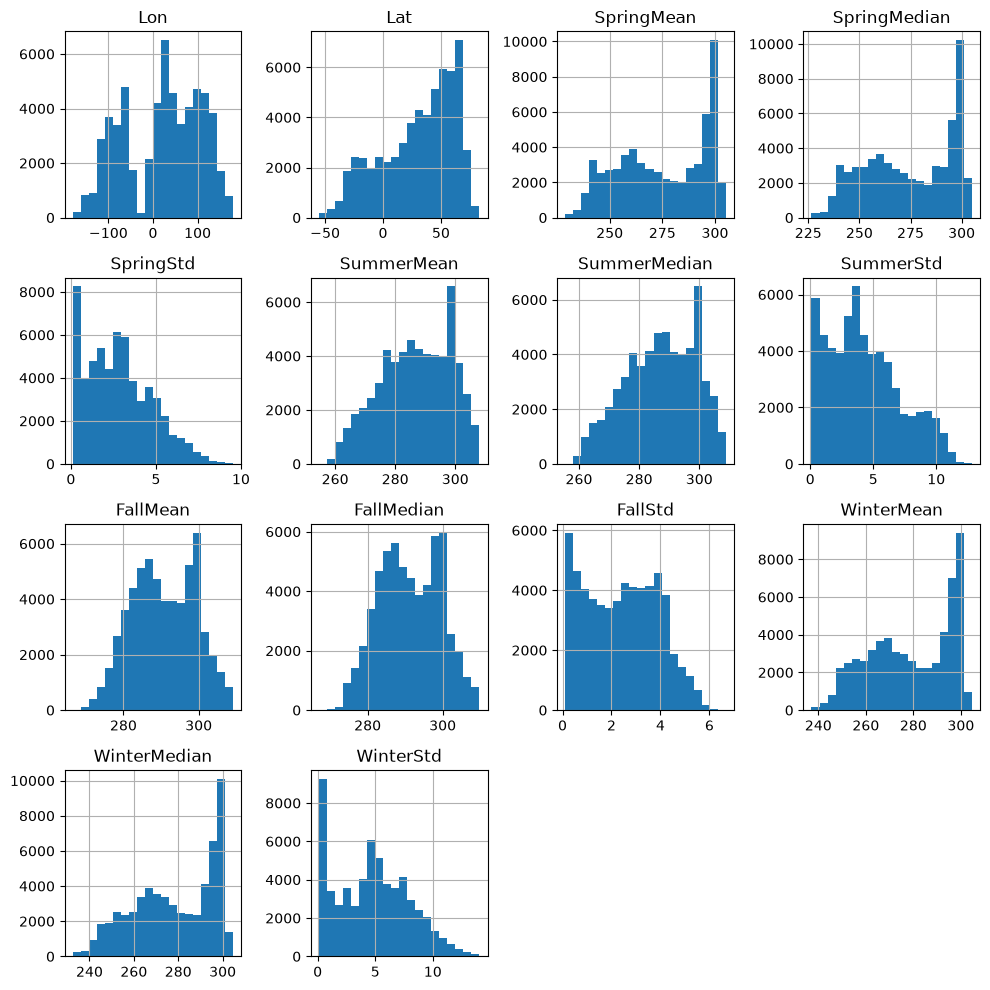

In [21]:
# Look at distributions of numerical values
stats_df["tmp"].hist(figsize=(10, 10), bins=20)
plt.tight_layout()
plt.show()

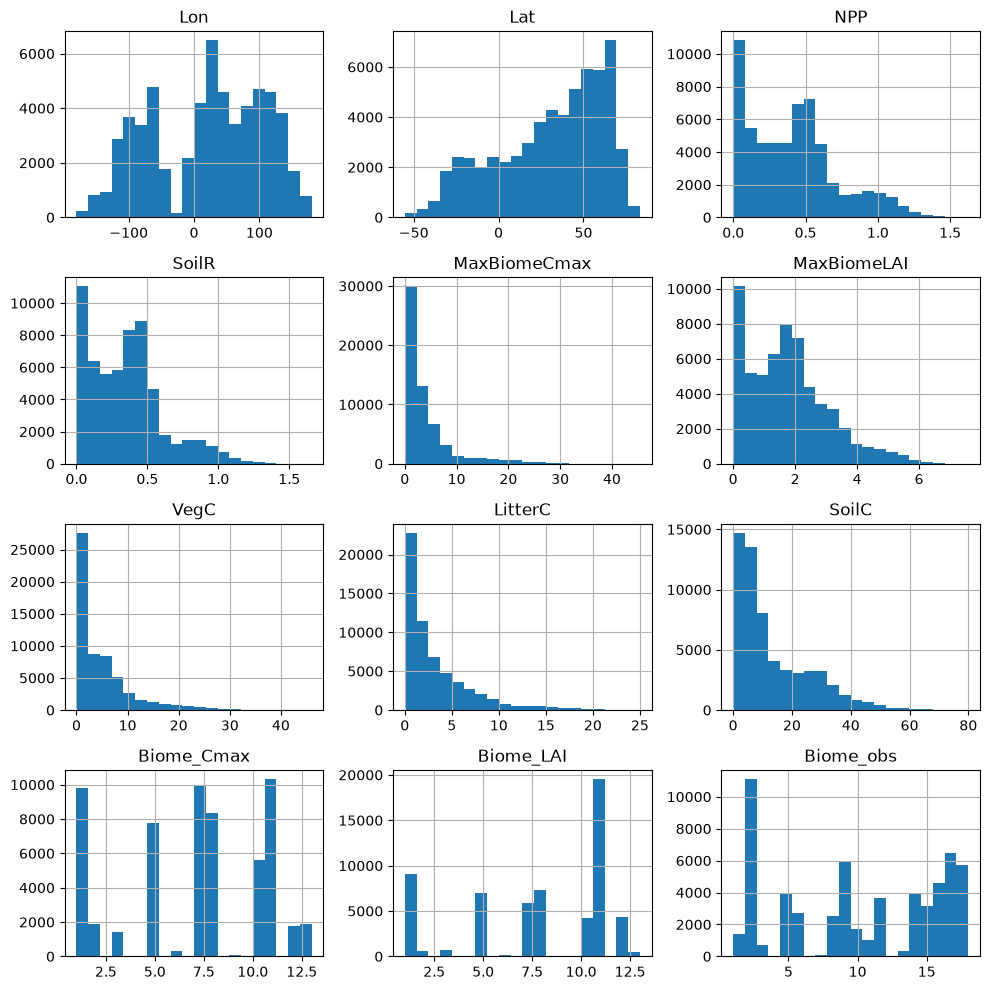

In [23]:
# Look at distributions of numerical values
lpj_df.hist(figsize=(10, 10), bins=20)
plt.tight_layout()
plt.show()

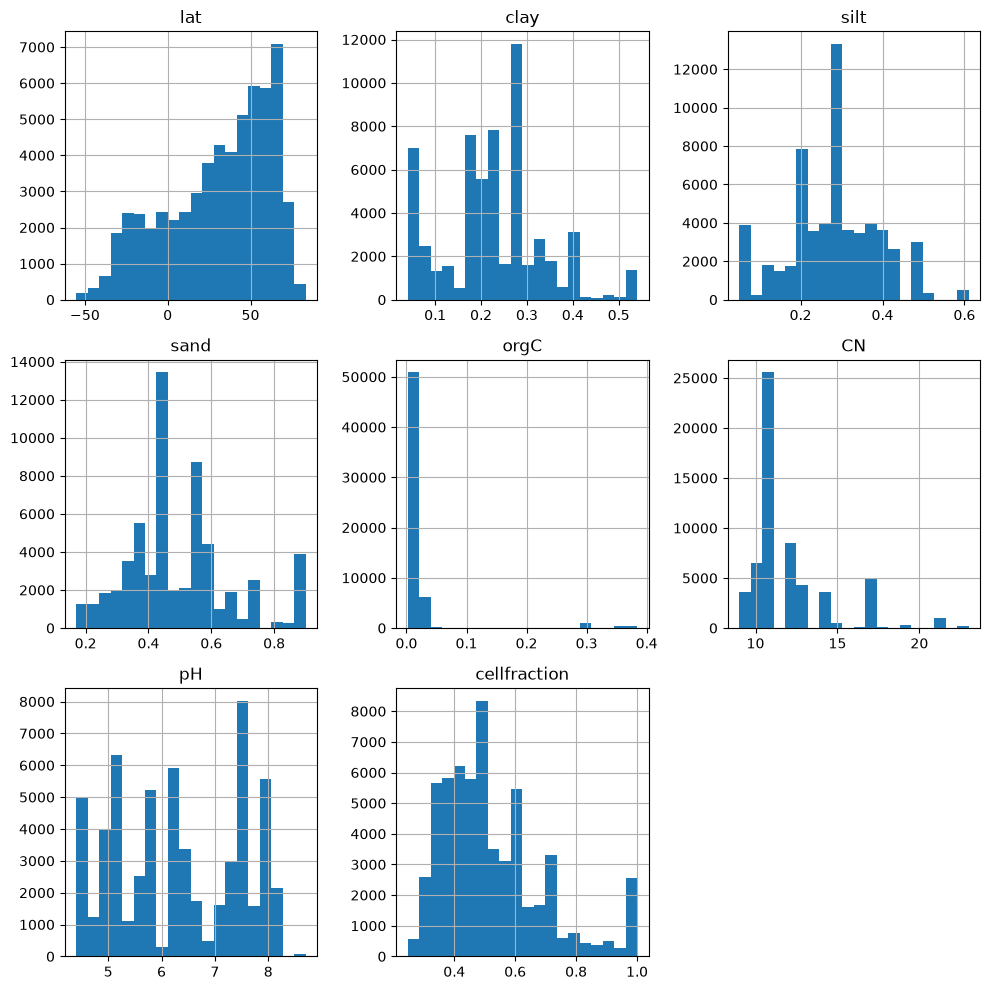

In [24]:
# Look at distributions of numerical values
soil_df.hist(figsize=(10, 10), bins=20)
plt.tight_layout()
plt.show()

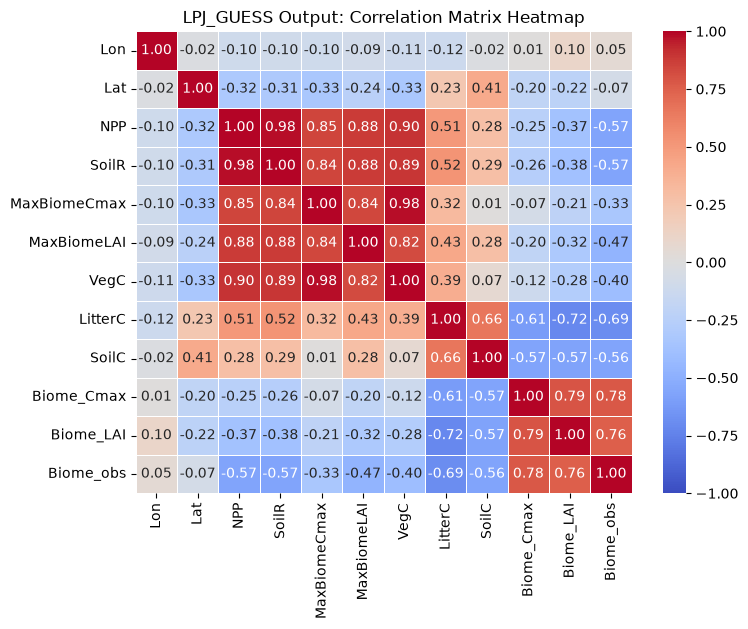

In [26]:
# Plot a correlation matrix
corr_matrix = lpj_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('LPJ_GUESS Output: Correlation Matrix Heatmap')
plt.show()

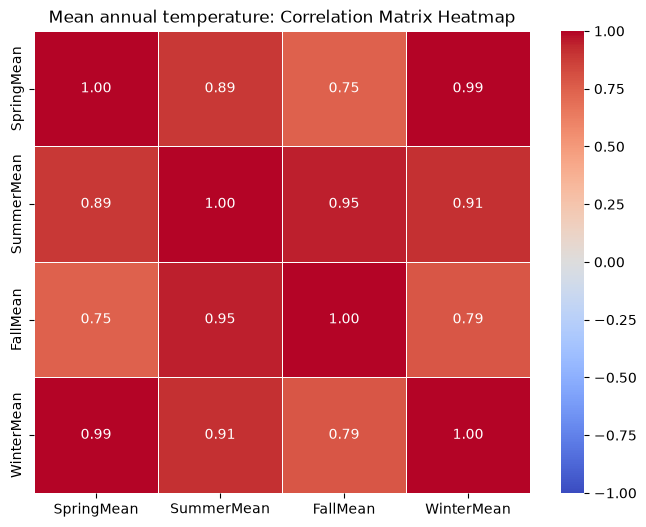

In [29]:
# Plot a correlation matrix
mean_cols = [
    'SpringMean',
    'SummerMean',
    'FallMean',
    'WinterMean'
]
corr_matrix = stats_df["tmp"][mean_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Mean annual temperature: Correlation Matrix Heatmap')
plt.show()

## 3. Binary classification

In this part, you are going to build a binary classifier to classify two classes of biomes from
“Biome_obs”. You can choose one of the biomes and try to train a classifier that can distinguish this biome from the other data, e.g, ’Arctic/alpine tundra’ or ’not Arctic/alpine tundra’.

One way to narrow down the data if you have trouble creating the binary classifier is to
only include samples from two different country codes or regions

### 3.1. Data split

Split your dataset into two parts: a training set and a test set. The training set is used to
train the model, and the test set is used to evaluate model performance. Think through
how you split your data and what fits your purpose. Ways to split your data could be
through climate, zone, biome, countries or continents. Are all the biomes represented in
both your train and test data? Are the frequency of biome classes representative?

### 3.2. Model training
Next, train a Random Forest binary classification model. You can start by using training
data from one smaller region (could be one country code). Evaluate your model and try to
optimise the hyperparameters.

### 3.3. Model evaluation
Evaluate the model's performance using appropriate metrics for binary classification. Common metrics include precision, recall, and to plot the predictions in a confusion matrix. Test the model trained on one part of the world on the same biome in another part of the world,
e.g., Arctic/alpine tundra in either North America or Siberia. Does the model show equal 
skill in both areas? Could the features you have chosen affect the skill of the model in another part of the world? Why?

### 3.4. Feature importance and model interpretation
Analyze which features played the most crucial role in your model's decisions. Finally, discuss and interpret your results comprehensively, and explore any misclassifications to gain valuable insights into how well machine learning models adapt to different continents and
environments. Are all features that you used for training necessary? Could you reduce the
number of features used? Were there features that you did not use that could be important? Why would they be important?
Optional: Plot the misclassified regions on a world map.